# Travel Order Resolver - Evaluation Notebook

This notebook runs comprehensive evaluations of the NLP pipeline and generates tables for `docs/BENCHMARK.md`.

**Key Principle**: All functions are imported from `src/evaluation/` - NO code duplication.

**Comprehensive Testing**: ALL models are tested in ALL sections to identify which pipeline stages benefit which models.

## Table of Contents
1. [Setup](#1-setup)
2. [Pre-Processing Impact](#2-pre-processing-impact)
3. [Component Comparison](#3-component-comparison)
4. [Post-Processing Impact](#4-post-processing-impact)
5. [Performance by Language](#5-performance-by-language)
6. [Language Detection Pipeline Value](#6-language-detection-pipeline-value)
7. [End-to-End Pipeline](#7-end-to-end-pipeline)
8. [Export Helper](#8-export-helper)

---
## 1. Setup

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /root/code/Romain-Ber/Epitech/T9-AIA/TravelOrderResolver


In [2]:
# Import everything from shared modules - NO local function definitions
from src.evaluation import (
    load_dataset,
    apply_preprocessing,
    create_language_detectors,
    create_intent_classifiers,
    create_entity_extractors,
    create_fuzzy_post_processor,
    # Basic formatting
    format_table_md,
    format_accuracy,
    format_latency,
    format_f1,
    # Sklearn-style reports (SAME functions used by CLI)
    format_language_report_md,
    format_intent_report_md,
    format_entity_report_md,
    # Confusion matrix
    compute_confusion_matrix,
    plot_confusion_matrix,
)
from src.evaluation.evaluators import (
    evaluate_language_detectors,
    evaluate_intent_classifiers,
    evaluate_entity_extractors,
)
from IPython.display import Markdown, display

print("Imports successful!")

Imports successful!


In [3]:
# Load dataset
DATASET_PATH = project_root / "datasets" / "augmented" / "test.csv"
raw_data = load_dataset(str(DATASET_PATH))
print(f"Loaded {len(raw_data)} samples from {DATASET_PATH.name}")

# Show distribution
intent_counts = {}
lang_counts = {}
for sample in raw_data:
    intent_counts[sample["intent"]] = intent_counts.get(sample["intent"], 0) + 1
    lang_counts[sample.get("language", "UNKNOWN")] = lang_counts.get(sample.get("language", "UNKNOWN"), 0) + 1

print(f"\nIntent distribution: {intent_counts}")
print(f"Language distribution: {lang_counts}")

Loaded 15005 samples from test.csv

Intent distribution: {'TRIP': 11101, 'NOT_TRIP': 3754, 'UNKNOWN': 150}
Language distribution: {'UNKNOWN': 673, 'FRENCH': 13366, 'ENGLISH': 966}


In [4]:
# Create pre-processed version using shared function
preprocessed_data = apply_preprocessing(raw_data, verbose=True)

Pre-processed 15005 samples (49 pure noise)


---
## 2. Pre-Processing Impact

Compare **ALL models** with and without pre-processing (STT filter + text normalization).

This helps identify which models benefit most from pre-processing.

In [5]:
# 2.1 Language Detection: ALL models - Raw vs Pre-processed
print("Evaluating ALL Language Detection models...")

ld_models = create_language_detectors(["all"])

ld_raw = evaluate_language_detectors(ld_models, raw_data)
ld_pre = evaluate_language_detectors(ld_models, preprocessed_data)

rows = []
for name in ld_raw.keys():
    raw_acc = ld_raw[name].accuracy
    pre_acc = ld_pre[name].accuracy
    delta = pre_acc - raw_acc
    rows.append([
        name,
        format_accuracy(raw_acc),
        format_accuracy(pre_acc),
        f"{delta:+.1%}",
    ])

print(format_table_md(["Model", "Raw", "Pre-processed", "Delta"], rows, "Language Detection: Pre-Processing Impact"))

Evaluating ALL Language Detection models...
  Evaluating language: Regex...
    Done. Accuracy: 67.5%
  Evaluating language: Langdetect...
    Done. Accuracy: 77.9%
  Evaluating language: Regex...
    Done. Accuracy: 67.5%
  Evaluating language: Langdetect...
    Done. Accuracy: 77.9%
### Language Detection: Pre-Processing Impact

| Model | Raw | Pre-processed | Delta |
|---|---|---|---|
| Regex | 67.5% | 67.5% | +0.0% |
| Langdetect | 77.9% | 77.9% | +0.0% |


In [6]:
# 2.2 Intent Classification: ALL models - Raw vs Pre-processed
print("Evaluating ALL Intent Classification models...")

ic_models = create_intent_classifiers(["all"])

ic_raw = evaluate_intent_classifiers(ic_models, raw_data)
ic_pre = evaluate_intent_classifiers(ic_models, preprocessed_data)

rows = []
for name in ic_raw.keys():
    raw_acc = ic_raw[name].accuracy
    pre_acc = ic_pre[name].accuracy
    delta = pre_acc - raw_acc
    rows.append([
        name,
        format_accuracy(raw_acc),
        format_accuracy(pre_acc),
        f"{delta:+.1%}",
    ])

print(format_table_md(["Model", "Raw", "Pre-processed", "Delta"], rows, "Intent Classification: Pre-Processing Impact"))

Evaluating ALL Intent Classification models...


/root/.cache/pypoetry/virtualenvs/travel-order-resolver-J1LD3U4O-py3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


CUDA available, using GPU: NVIDIA GeForce RTX 2060
Loading CamemBERT for zero-shot classification: almanach/camembert-base...


Some weights of CamembertForSequenceClassification were not initialized from the model checkpoint at almanach/camembert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda
Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.


CamemBERT intent classifier ready (device: cuda)
SpaCy: GPU not available, using CPU
Loading spaCy model for intent: fr_core_news_lg...


/root/.cache/pypoetry/virtualenvs/travel-order-resolver-J1LD3U4O-py3.10/lib/python3.10/site-packages/spacy/util.py:969: UserWarning: [W095] Model 'fr_core_news_lg' (3.7.0) was trained with spaCy v3.7.0 and may not be 100% compatible with the current version (3.8.11). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


SpaCy intent model loaded successfully (device: CPU)
  Evaluating intent: Regex...
    Progress: 0/15005 (0%)
    Progress: 128/15005 (1%)
    Progress: 256/15005 (2%)
    Progress: 384/15005 (3%)
    Progress: 512/15005 (3%)
    Progress: 640/15005 (4%)
    Progress: 768/15005 (5%)
    Progress: 896/15005 (6%)
    Progress: 1024/15005 (7%)
    Progress: 1152/15005 (8%)
    Progress: 1280/15005 (9%)
    Progress: 1408/15005 (9%)
    Progress: 1536/15005 (10%)
    Progress: 1664/15005 (11%)
    Progress: 1792/15005 (12%)
    Progress: 1920/15005 (13%)
    Progress: 2048/15005 (14%)
    Progress: 2176/15005 (15%)
    Progress: 2304/15005 (15%)
    Progress: 2432/15005 (16%)
    Progress: 2560/15005 (17%)
    Progress: 2688/15005 (18%)
    Progress: 2816/15005 (19%)
    Progress: 2944/15005 (20%)
    Progress: 3072/15005 (20%)
    Progress: 3200/15005 (21%)
    Progress: 3328/15005 (22%)
    Progress: 3456/15005 (23%)
    Progress: 3584/15005 (24%)
    Progress: 3712/15005 (25%)
    Progr

In [7]:
# 2.3 Entity Extraction: ALL models - Raw vs Pre-processed
print("Evaluating ALL Entity Extraction models...")

ee_models = create_entity_extractors(["all"])

ee_raw = evaluate_entity_extractors(ee_models, raw_data)
ee_pre = evaluate_entity_extractors(ee_models, preprocessed_data)

rows = []
for name in ee_raw.keys():
    raw_acc = ee_raw[name].accuracy
    pre_acc = ee_pre[name].accuracy
    delta = pre_acc - raw_acc
    rows.append([
        name,
        format_accuracy(raw_acc),
        format_accuracy(pre_acc),
        f"{delta:+.1%}",
    ])

print(format_table_md(["Model", "Raw", "Pre-processed", "Delta"], rows, "Entity Extraction: Pre-Processing Impact"))

Evaluating ALL Entity Extraction models...
SpaCy: GPU not available, using CPU
Loading spaCy model: fr_core_news_lg...
SpaCy model loaded successfully (device: CPU)
CUDA available, using GPU: NVIDIA GeForce RTX 2060
Loading CamemBERT base model: almanach/camembert-base...
Precomputing station embeddings...
Computed embeddings for 2631 cities
CamemBERT zero-shot extractor ready (device: cuda, threshold: 0.85)
  Evaluating entity: Regex...
    Progress: 0/11101 (0%)
    Progress: 128/11101 (1%)
    Progress: 256/11101 (2%)
    Progress: 384/11101 (3%)
    Progress: 512/11101 (5%)
    Progress: 640/11101 (6%)
    Progress: 768/11101 (7%)
    Progress: 896/11101 (8%)
    Progress: 1024/11101 (9%)
    Progress: 1152/11101 (10%)
    Progress: 1280/11101 (12%)
    Progress: 1408/11101 (13%)
    Progress: 1536/11101 (14%)
    Progress: 1664/11101 (15%)
    Progress: 1792/11101 (16%)
    Progress: 1920/11101 (17%)
    Progress: 2048/11101 (18%)
    Progress: 2176/11101 (20%)
    Progress: 2304/

---
## 3. Component Comparison

Compare all models for each component (using pre-processed data).

This shows the baseline performance of each model.

In [8]:
# 3.1 Language Detection Models - Sklearn-style reports
print("Language Detection Models - Sklearn-style Classification Reports")
print("=" * 60)

# Re-use ld_pre from Section 2
for name, result in ld_pre.items():
    report_md = format_language_report_md(name, result)
    display(Markdown(report_md))
    print()  # spacing

Language Detection Models - Sklearn-style Classification Reports


### Language Detection: Regex

|              | Precision | Recall |   F1 | Support |
|--------------|-----------|--------|------|---------|
| fr           |      0.98 |   0.68 | 0.80 |   13366 |
| en           |      0.70 |   0.66 | 0.68 |     966 |
| unk          |      0.09 |   0.68 | 0.16 |     673 |
|              |           |        |      |         |
| accuracy     |           |        | 0.67 |   15005 |
| macro avg    |      0.59 |   0.67 | 0.55 |   15005 |
| latency      |           |        |      |   0.0ms |

### Language Detection: Langdetect

|              | Precision | Recall |   F1 | Support |
|--------------|-----------|--------|------|---------|
| fr           |      0.96 |   0.80 | 0.87 |   13366 |
| en           |      0.48 |   0.66 | 0.55 |     966 |
| unk          |      0.14 |   0.55 | 0.23 |     673 |
|              |           |        |      |         |
| accuracy     |           |        | 0.78 |   15005 |
| macro avg    |      0.53 |   0.67 | 0.55 |   15005 |
| latency      |           |        |      |   6.1ms |

In [9]:
# 3.2 Intent Classification Models - Sklearn-style reports
print("Intent Classification Models - Sklearn-style Classification Reports")
print("=" * 60)

# Re-use ic_pre from Section 2
for name, result in ic_pre.items():
    report_md = format_intent_report_md(name, result)
    display(Markdown(report_md))
    print()  # spacing

Intent Classification Models - Sklearn-style Classification Reports


### Intent Classification: Regex

|              | Precision | Recall |   F1 | Support |
|--------------|-----------|--------|------|---------|
| TRIP         |      0.76 |   0.80 | 0.78 |   11101 |
| NOT_TRIP     |      0.29 |   0.25 | 0.27 |    3754 |
| UNKNOWN      |      0.75 |   0.42 | 0.54 |     150 |
|              |           |        |      |         |
| accuracy     |           |        | 0.66 |   15005 |
| macro avg    |      0.60 |   0.49 | 0.53 |   15005 |
| latency      |           |        |      |   0.0ms |

### Intent Classification: CamemBERT

|              | Precision | Recall |   F1 | Support |
|--------------|-----------|--------|------|---------|
| TRIP         |      0.79 |   0.13 | 0.23 |   11101 |
| NOT_TRIP     |      0.26 |   0.89 | 0.40 |    3754 |
| UNKNOWN      |      0.75 |   0.42 | 0.54 |     150 |
|              |           |        |      |         |
| accuracy     |           |        | 0.32 |   15005 |
| macro avg    |      0.60 |   0.48 | 0.39 |   15005 |
| latency      |           |        |      |   6.4ms |

### Intent Classification: SpaCy

|              | Precision | Recall |   F1 | Support |
|--------------|-----------|--------|------|---------|
| TRIP         |      0.94 |   0.78 | 0.85 |   11101 |
| NOT_TRIP     |      0.56 |   0.85 | 0.67 |    3754 |
| UNKNOWN      |      0.00 |   0.00 | 0.00 |     150 |
|              |           |        |      |         |
| accuracy     |           |        | 0.79 |   15005 |
| macro avg    |      0.50 |   0.54 | 0.51 |   15005 |
| latency      |           |        |      |   0.8ms |

In [10]:
# 3.3 Entity Extraction Models - Sklearn-style reports
print("Entity Extraction Models - Sklearn-style Classification Reports")
print("=" * 60)

# Re-use ee_pre from Section 2
for name, result in ee_pre.items():
    report_md = format_entity_report_md(name, result)
    display(Markdown(report_md))
    print()  # spacing

Entity Extraction Models - Sklearn-style Classification Reports


### Entity Extraction: Regex

|              | Precision | Recall |   F1 | Support |
|--------------|-----------|--------|------|---------|
| departure    |      0.45 |   0.44 | 0.45 |    9834 |
| destination  |      0.49 |   0.43 | 0.46 |   11000 |
|              |           |        |      |         |
| accuracy     |           |        | 0.33 |   11101 |
| macro avg    |      0.47 |   0.44 | 0.45 |   11101 |
| latency      |           |        |      |   0.0ms |

### Entity Extraction: SpaCy

|              | Precision | Recall |   F1 | Support |
|--------------|-----------|--------|------|---------|
| departure    |      0.64 |   0.32 | 0.43 |    9834 |
| destination  |      0.53 |   0.42 | 0.47 |   11000 |
|              |           |        |      |         |
| accuracy     |           |        | 0.28 |   11101 |
| macro avg    |      0.58 |   0.37 | 0.45 |   11101 |
| latency      |           |        |      |   0.9ms |

### Entity Extraction: CamemBERT

|              | Precision | Recall |   F1 | Support |
|--------------|-----------|--------|------|---------|
| departure    |      0.51 |   0.24 | 0.33 |    9834 |
| destination  |      0.40 |   0.35 | 0.37 |   11000 |
|              |           |        |      |         |
| accuracy     |           |        | 0.16 |   11101 |
| macro avg    |      0.46 |   0.30 | 0.35 |   11101 |
| latency      |           |        |      |   0.7ms |

### 3.4 Confusion Matrices

Visualize confusion matrices for the best-performing models.

Generating confusion matrices...
SpaCy: GPU not available, using CPU
Loading spaCy model for intent: fr_core_news_lg...
SpaCy intent model loaded successfully (device: CPU)
  Evaluating intent: SpaCy...
    Using batched inference (batch_size=128)...
    Progress: 0/15005 (0%)
    Progress: 128/15005 (1%)
    Progress: 256/15005 (2%)
    Progress: 384/15005 (3%)
    Progress: 512/15005 (3%)
    Progress: 640/15005 (4%)
    Progress: 768/15005 (5%)
    Progress: 896/15005 (6%)
    Progress: 1024/15005 (7%)
    Progress: 1152/15005 (8%)
    Progress: 1280/15005 (9%)
    Progress: 1408/15005 (9%)
    Progress: 1536/15005 (10%)
    Progress: 1664/15005 (11%)
    Progress: 1792/15005 (12%)
    Progress: 1920/15005 (13%)
    Progress: 2048/15005 (14%)
    Progress: 2176/15005 (15%)
    Progress: 2304/15005 (15%)
    Progress: 2432/15005 (16%)
    Progress: 2560/15005 (17%)
    Progress: 2688/15005 (18%)
    Progress: 2816/15005 (19%)
    Progress: 2944/15005 (20%)
    Progress: 3072/15005 (2

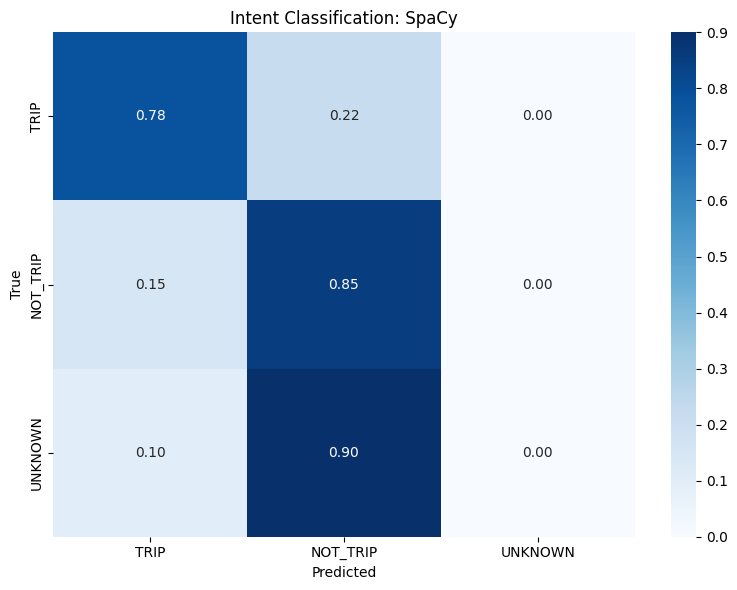

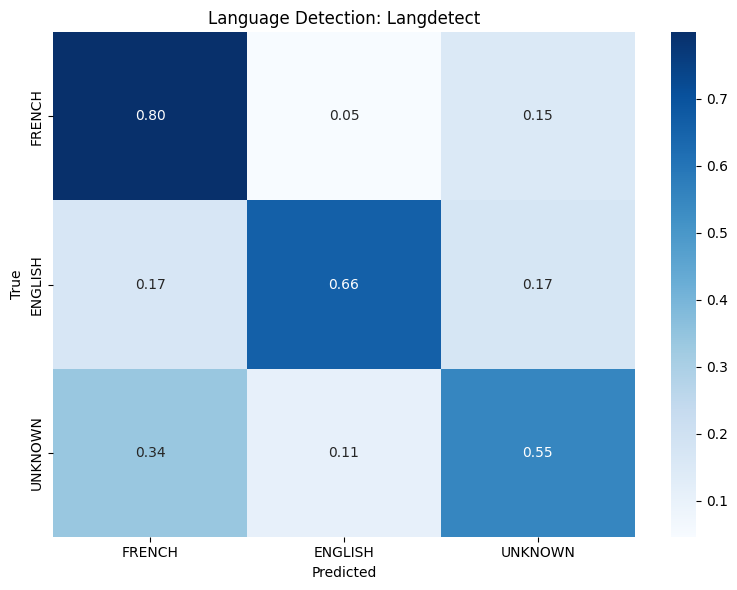

Confusion matrices generated!


In [11]:
# 3.4 Confusion Matrices for best models
# Re-evaluate with return_predictions=True to get y_true/y_pred

print("Generating confusion matrices...")

# Intent Classification - SpaCy (typically best)
ic_models_single = create_intent_classifiers(["spacy"])
ic_results, ic_preds = evaluate_intent_classifiers(
    ic_models_single, preprocessed_data, return_predictions=True
)

# Language Detection - Langdetect
ld_models_single = create_language_detectors(["langdetect"])
ld_results, ld_preds = evaluate_language_detectors(
    ld_models_single, preprocessed_data, return_predictions=True
)

# Plot confusion matrices
import matplotlib.pyplot as plt

# Intent Classification Confusion Matrix
y_true, y_pred = ic_preds["SpaCy"]
matrix, labels = compute_confusion_matrix(y_true, y_pred, labels=["TRIP", "NOT_TRIP", "UNKNOWN"])
fig = plot_confusion_matrix(matrix, labels, title="Intent Classification: SpaCy", normalize=True)
plt.show()

# Language Detection Confusion Matrix
y_true, y_pred = ld_preds["Langdetect"]
matrix, labels = compute_confusion_matrix(y_true, y_pred, labels=["FRENCH", "ENGLISH", "UNKNOWN"])
fig = plot_confusion_matrix(matrix, labels, title="Language Detection: Langdetect", normalize=True)
plt.show()

print("Confusion matrices generated!")

---
## 4. Post-Processing Impact

Compare **ALL Entity Extraction models** with and without Fuzzy post-processing.

This helps identify which models benefit most from fuzzy matching.

In [13]:
# 4.1 Entity Extraction: ALL models with and without Fuzzy
print("Evaluating ALL Entity Extraction models with Fuzzy post-processing...")

fuzzy_post = create_fuzzy_post_processor()
ee_all_models = create_entity_extractors(["all"])

# Without fuzzy - re-use ee_pre from Section 2
ee_no_fuzzy = ee_pre

# With fuzzy
ee_with_fuzzy = evaluate_entity_extractors(
    ee_all_models, preprocessed_data, fuzzy_post=fuzzy_post, normalize_fuzzy=True
)

rows = []
for name in ee_no_fuzzy.keys():
    no_fuzzy_acc = ee_no_fuzzy[name].accuracy
    # Keys in ee_with_fuzzy have " + Fuzzy" suffix
    fuzzy_key = f"{name} + Fuzzy"
    with_fuzzy_acc = ee_with_fuzzy[fuzzy_key].accuracy
    delta = with_fuzzy_acc - no_fuzzy_acc
    rows.append([
        name,
        format_accuracy(no_fuzzy_acc),
        format_accuracy(with_fuzzy_acc),
        f"{delta:+.1%}",
        format_latency(ee_no_fuzzy[name].avg_latency_ms),
        format_latency(ee_with_fuzzy[fuzzy_key].avg_latency_ms),
    ])

print(format_table_md(
    ["Model", "No Fuzzy", "+Fuzzy", "Delta", "Latency (no)", "Latency (+)"],
    rows,
    "Entity Extraction: Fuzzy Post-Processing Impact"
))

Evaluating ALL Entity Extraction models with Fuzzy post-processing...
Loaded 6078 SNCF stations from StationDatabase
Fuzzy matching threshold: 80%
SpaCy: GPU not available, using CPU
Loading spaCy model: fr_core_news_lg...
SpaCy model loaded successfully (device: CPU)
CUDA available, using GPU: NVIDIA GeForce RTX 2060
Loading CamemBERT base model: almanach/camembert-base...
Precomputing station embeddings...
Computed embeddings for 2631 cities
CamemBERT zero-shot extractor ready (device: cuda, threshold: 0.85)
  Evaluating entity: Regex + Fuzzy...
    Progress: 0/11101 (0%)
    Progress: 128/11101 (1%)
    Progress: 256/11101 (2%)
    Progress: 384/11101 (3%)
    Progress: 512/11101 (5%)
    Progress: 640/11101 (6%)
    Progress: 768/11101 (7%)
    Progress: 896/11101 (8%)
    Progress: 1024/11101 (9%)
    Progress: 1152/11101 (10%)
    Progress: 1280/11101 (12%)
    Progress: 1408/11101 (13%)
    Progress: 1536/11101 (14%)
    Progress: 1664/11101 (15%)
    Progress: 1792/11101 (16%)


---
## 5. Performance by Language

Segment evaluation results by ground-truth language for **ALL models**.

This helps identify which models work best for which languages.

In [14]:
# Segment dataset by ground-truth language
fr_samples = [s for s in preprocessed_data if s.get("language") == "FRENCH"]
en_samples = [s for s in preprocessed_data if s.get("language") == "ENGLISH"]
unk_samples = [s for s in preprocessed_data if s.get("language") not in ["FRENCH", "ENGLISH"]]

print(f"French samples: {len(fr_samples)}")
print(f"English samples: {len(en_samples)}")
print(f"Unknown/Other samples: {len(unk_samples)}")

# For Entity Extraction, filter to TRIP only
fr_trip = [s for s in fr_samples if s.get("intent") == "TRIP"]
en_trip = [s for s in en_samples if s.get("intent") == "TRIP"]
unk_trip = [s for s in unk_samples if s.get("intent") == "TRIP"]

print(f"\nTRIP samples - FR: {len(fr_trip)}, EN: {len(en_trip)}, UNK: {len(unk_trip)}")

French samples: 13366
English samples: 966
Unknown/Other samples: 673

TRIP samples - FR: 9990, EN: 666, UNK: 445


In [15]:
# 5.1 Intent Classification: ALL models by Language
print("Evaluating ALL Intent Classification models by language...")

ic_all = create_intent_classifiers(["all"])

ic_fr = evaluate_intent_classifiers(ic_all, fr_samples) if fr_samples else {}
ic_en = evaluate_intent_classifiers(ic_all, en_samples) if en_samples else {}
ic_unk = evaluate_intent_classifiers(ic_all, unk_samples) if unk_samples else {}

rows = []
for name in ic_fr.keys():
    rows.append([
        name,
        format_accuracy(ic_fr[name].accuracy) if ic_fr else "N/A",
        format_accuracy(ic_en[name].accuracy) if ic_en else "N/A",
        format_accuracy(ic_unk[name].accuracy) if ic_unk else "N/A",
    ])

print(format_table_md(
    ["Model", f"FR ({len(fr_samples)})", f"EN ({len(en_samples)})", f"UNK ({len(unk_samples)})"],
    rows,
    "Intent Classification by Ground-Truth Language"
))

Evaluating ALL Intent Classification models by language...
CUDA available, using GPU: NVIDIA GeForce RTX 2060
Loading CamemBERT for zero-shot classification: almanach/camembert-base...


Some weights of CamembertForSequenceClassification were not initialized from the model checkpoint at almanach/camembert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda
Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.


CamemBERT intent classifier ready (device: cuda)
SpaCy: GPU not available, using CPU
Loading spaCy model for intent: fr_core_news_lg...
SpaCy intent model loaded successfully (device: CPU)
  Evaluating intent: Regex...
    Progress: 0/13366 (0%)
    Progress: 128/13366 (1%)
    Progress: 256/13366 (2%)
    Progress: 384/13366 (3%)
    Progress: 512/13366 (4%)
    Progress: 640/13366 (5%)
    Progress: 768/13366 (6%)
    Progress: 896/13366 (7%)
    Progress: 1024/13366 (8%)
    Progress: 1152/13366 (9%)
    Progress: 1280/13366 (10%)
    Progress: 1408/13366 (11%)
    Progress: 1536/13366 (11%)
    Progress: 1664/13366 (12%)
    Progress: 1792/13366 (13%)
    Progress: 1920/13366 (14%)
    Progress: 2048/13366 (15%)
    Progress: 2176/13366 (16%)
    Progress: 2304/13366 (17%)
    Progress: 2432/13366 (18%)
    Progress: 2560/13366 (19%)
    Progress: 2688/13366 (20%)
    Progress: 2816/13366 (21%)
    Progress: 2944/13366 (22%)
    Progress: 3072/13366 (23%)
    Progress: 3200/13366 (

In [16]:
# 5.2 Entity Extraction: ALL models by Language (TRIP only, with Fuzzy)
print("Evaluating ALL Entity Extraction models by language...")

ee_all = create_entity_extractors(["all"])
fuzzy = create_fuzzy_post_processor()

ee_fr = evaluate_entity_extractors(ee_all, fr_trip, fuzzy_post=fuzzy, normalize_fuzzy=True) if fr_trip else {}
ee_en = evaluate_entity_extractors(ee_all, en_trip, fuzzy_post=fuzzy, normalize_fuzzy=True) if en_trip else {}
ee_unk = evaluate_entity_extractors(ee_all, unk_trip, fuzzy_post=fuzzy, normalize_fuzzy=True) if unk_trip else {}

rows = []
for name in ee_fr.keys():
    rows.append([
        name,
        format_accuracy(ee_fr[name].accuracy) if ee_fr else "N/A",
        format_accuracy(ee_en[name].accuracy) if ee_en else "N/A",
        format_accuracy(ee_unk[name].accuracy) if ee_unk else "N/A",
    ])

print(format_table_md(
    ["Model (+Fuzzy)", f"FR ({len(fr_trip)})", f"EN ({len(en_trip)})", f"UNK ({len(unk_trip)})"],
    rows,
    "Entity Extraction by Ground-Truth Language (TRIP only)"
))

Evaluating ALL Entity Extraction models by language...
SpaCy: GPU not available, using CPU
Loading spaCy model: fr_core_news_lg...
SpaCy model loaded successfully (device: CPU)
CUDA available, using GPU: NVIDIA GeForce RTX 2060
Loading CamemBERT base model: almanach/camembert-base...
Precomputing station embeddings...
Computed embeddings for 2631 cities
CamemBERT zero-shot extractor ready (device: cuda, threshold: 0.85)
Loaded 6078 SNCF stations from StationDatabase
Fuzzy matching threshold: 80%
  Evaluating entity: Regex + Fuzzy...
    Progress: 0/9990 (0%)
    Progress: 128/9990 (1%)
    Progress: 256/9990 (3%)
    Progress: 384/9990 (4%)
    Progress: 512/9990 (5%)
    Progress: 640/9990 (6%)
    Progress: 768/9990 (8%)
    Progress: 896/9990 (9%)
    Progress: 1024/9990 (10%)
    Progress: 1152/9990 (12%)
    Progress: 1280/9990 (13%)
    Progress: 1408/9990 (14%)
    Progress: 1536/9990 (15%)
    Progress: 1664/9990 (17%)
    Progress: 1792/9990 (18%)
    Progress: 1920/9990 (19%)

---
## 6. Language Detection Pipeline Value

Does adding Language Detection as a filtering step improve downstream performance?

Test **ALL models** to see which benefit from LD filtering.

Compare:
- **Baseline**: Run IC/EE on all samples
- **LD-Filtered**: Run LD first, then IC/EE only on LD-predicted-French samples

In [17]:
# Run Language Detection on all samples to create filtered dataset
print("Running Language Detection to filter samples...")

from src.nlp.language import LangdetectLanguageDetector
ld = LangdetectLanguageDetector()

# Predict language for each sample
ld_predictions = []
for sample in preprocessed_data:
    lang, conf = ld.detect(sample["sentence"])
    ld_predictions.append(lang)

# Filter to LD-predicted French
ld_french_samples = [
    sample for sample, pred in zip(preprocessed_data, ld_predictions)
    if pred == "FRENCH"
]

# For Entity, filter to TRIP
full_trip = [s for s in preprocessed_data if s.get("intent") == "TRIP"]
filtered_trip = [s for s in ld_french_samples if s.get("intent") == "TRIP"]

print(f"LD predicted {len(ld_french_samples)} samples as FRENCH out of {len(preprocessed_data)} total")
print(f"LD filter rate: {len(ld_french_samples)/len(preprocessed_data):.1%}")
print(f"TRIP samples - Full: {len(full_trip)}, Filtered: {len(filtered_trip)}")

Running Language Detection to filter samples...
LD predicted 11077 samples as FRENCH out of 15005 total
LD filter rate: 73.8%
TRIP samples - Full: 11101, Filtered: 8740


In [18]:
# 6.1 Intent Classification: ALL models - Full dataset vs LD-filtered
print("Comparing ALL Intent Classification models with and without LD filtering...")

ic_all = create_intent_classifiers(["all"])

# Re-use ic_pre from Section 2 for full dataset
ic_full = ic_pre
ic_filtered = evaluate_intent_classifiers(ic_all, ld_french_samples)

rows = []
for name in ic_full.keys():
    full_acc = ic_full[name].accuracy
    filt_acc = ic_filtered[name].accuracy
    delta = filt_acc - full_acc
    rows.append([
        name,
        format_accuracy(full_acc),
        format_accuracy(filt_acc),
        f"{delta:+.1%}",
    ])

print(format_table_md(
    ["Model", f"Full ({len(preprocessed_data)})", f"LD-Filtered ({len(ld_french_samples)})", "Delta"],
    rows,
    "Intent Classification: LD Pipeline Value"
))

Comparing ALL Intent Classification models with and without LD filtering...
CUDA available, using GPU: NVIDIA GeForce RTX 2060
Loading CamemBERT for zero-shot classification: almanach/camembert-base...


Some weights of CamembertForSequenceClassification were not initialized from the model checkpoint at almanach/camembert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda
Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.


CamemBERT intent classifier ready (device: cuda)
SpaCy: GPU not available, using CPU
Loading spaCy model for intent: fr_core_news_lg...
SpaCy intent model loaded successfully (device: CPU)
  Evaluating intent: Regex...
    Progress: 0/11077 (0%)
    Progress: 128/11077 (1%)
    Progress: 256/11077 (2%)
    Progress: 384/11077 (3%)
    Progress: 512/11077 (5%)
    Progress: 640/11077 (6%)
    Progress: 768/11077 (7%)
    Progress: 896/11077 (8%)
    Progress: 1024/11077 (9%)
    Progress: 1152/11077 (10%)
    Progress: 1280/11077 (12%)
    Progress: 1408/11077 (13%)
    Progress: 1536/11077 (14%)
    Progress: 1664/11077 (15%)
    Progress: 1792/11077 (16%)
    Progress: 1920/11077 (17%)
    Progress: 2048/11077 (18%)
    Progress: 2176/11077 (20%)
    Progress: 2304/11077 (21%)
    Progress: 2432/11077 (22%)
    Progress: 2560/11077 (23%)
    Progress: 2688/11077 (24%)
    Progress: 2816/11077 (25%)
    Progress: 2944/11077 (27%)
    Progress: 3072/11077 (28%)
    Progress: 3200/11077 

In [19]:
# 6.2 Entity Extraction: ALL models - Full dataset vs LD-filtered (with Fuzzy)
print("Comparing ALL Entity Extraction models with and without LD filtering...")

ee_all = create_entity_extractors(["all"])
fuzzy = create_fuzzy_post_processor()

# Re-use ee_with_fuzzy from Section 4 for full dataset
ee_full = ee_with_fuzzy
ee_filtered = evaluate_entity_extractors(ee_all, filtered_trip, fuzzy_post=fuzzy, normalize_fuzzy=True)

rows = []
for name in ee_full.keys():
    full_acc = ee_full[name].accuracy
    filt_acc = ee_filtered[name].accuracy
    delta = filt_acc - full_acc
    rows.append([
        name,
        format_accuracy(full_acc),
        format_accuracy(filt_acc),
        f"{delta:+.1%}",
    ])

print(format_table_md(
    ["Model (+Fuzzy)", f"Full TRIP ({len(full_trip)})", f"LD-Filtered TRIP ({len(filtered_trip)})", "Delta"],
    rows,
    "Entity Extraction: LD Pipeline Value"
))

Comparing ALL Entity Extraction models with and without LD filtering...
SpaCy: GPU not available, using CPU
Loading spaCy model: fr_core_news_lg...
SpaCy model loaded successfully (device: CPU)
CUDA available, using GPU: NVIDIA GeForce RTX 2060
Loading CamemBERT base model: almanach/camembert-base...
Precomputing station embeddings...
Computed embeddings for 2631 cities
CamemBERT zero-shot extractor ready (device: cuda, threshold: 0.85)
Loaded 6078 SNCF stations from StationDatabase
Fuzzy matching threshold: 80%
  Evaluating entity: Regex + Fuzzy...
    Progress: 0/8740 (0%)
    Progress: 128/8740 (1%)
    Progress: 256/8740 (3%)
    Progress: 384/8740 (4%)
    Progress: 512/8740 (6%)
    Progress: 640/8740 (7%)
    Progress: 768/8740 (9%)
    Progress: 896/8740 (10%)
    Progress: 1024/8740 (12%)
    Progress: 1152/8740 (13%)
    Progress: 1280/8740 (15%)
    Progress: 1408/8740 (16%)
    Progress: 1536/8740 (18%)
    Progress: 1664/8740 (19%)
    Progress: 1792/8740 (21%)
    Progres

---
## 7. End-to-End Pipeline

Summary of best configurations for the full pipeline.

In [20]:
# Find best models from previous results
print("Generating End-to-End Pipeline Summary...")

# Best LD (highest accuracy from ld_pre)
best_ld_name = max(ld_pre.keys(), key=lambda x: ld_pre[x].accuracy)
best_ld_result = ld_pre[best_ld_name]

# Best IC (highest accuracy from ic_pre)
best_ic_name = max(ic_pre.keys(), key=lambda x: ic_pre[x].accuracy)
best_ic_result = ic_pre[best_ic_name]

# Best EE (highest accuracy from ee_with_fuzzy)
# Note: ee_with_fuzzy keys already have " + Fuzzy" suffix
best_ee_key = max(ee_with_fuzzy.keys(), key=lambda x: ee_with_fuzzy[x].accuracy)
best_ee_result = ee_with_fuzzy[best_ee_key]
# Extract base name without " + Fuzzy" suffix for display
best_ee_name = best_ee_key.replace(" + Fuzzy", "")

rows = [
    ["Pre-Processing", "STT Filter + Normalizer", "-", "<1ms"],
    ["Language Detection", best_ld_name, format_accuracy(best_ld_result.accuracy), format_latency(best_ld_result.avg_latency_ms)],
    ["Intent Classification", best_ic_name, format_accuracy(best_ic_result.accuracy), format_latency(best_ic_result.avg_latency_ms)],
    ["Entity Extraction", f"{best_ee_name} + Fuzzy", format_accuracy(best_ee_result.accuracy), format_latency(best_ee_result.avg_latency_ms)],
]

print(format_table_md(["Pipeline Stage", "Best Model", "Accuracy", "Latency"], rows, "End-to-End Pipeline Summary"))

Generating End-to-End Pipeline Summary...
### End-to-End Pipeline Summary

| Pipeline Stage | Best Model | Accuracy | Latency |
|---|---|---|---|
| Pre-Processing | STT Filter + Normalizer | - | <1ms |
| Language Detection | Langdetect | 77.9% | 6.1ms |
| Intent Classification | SpaCy | 79.1% | 0.8ms |
| Entity Extraction | Regex + Fuzzy | 57.1% | 9.8ms |


In [21]:
# Summary: Impact of each pipeline stage
print("\n" + "="*60)
print("SUMMARY: Pipeline Stage Impact Analysis")
print("="*60)

# Pre-processing impact (average across models)
ic_preproc_deltas = [ic_pre[n].accuracy - ic_raw[n].accuracy for n in ic_raw.keys()]
ee_preproc_deltas = [ee_pre[n].accuracy - ee_raw[n].accuracy for n in ee_raw.keys()]
avg_preproc_impact = (sum(ic_preproc_deltas) + sum(ee_preproc_deltas)) / (len(ic_preproc_deltas) + len(ee_preproc_deltas))

# Fuzzy impact (average across models)
# Note: ee_with_fuzzy keys have " + Fuzzy" suffix, ee_no_fuzzy keys don't
fuzzy_deltas = [ee_with_fuzzy[f"{n} + Fuzzy"].accuracy - ee_no_fuzzy[n].accuracy for n in ee_no_fuzzy.keys()]
avg_fuzzy_impact = sum(fuzzy_deltas) / len(fuzzy_deltas)

# LD filtering impact (average across models)
ic_ld_deltas = [ic_filtered[n].accuracy - ic_full[n].accuracy for n in ic_full.keys()]
ee_ld_deltas = [ee_filtered[n].accuracy - ee_full[n].accuracy for n in ee_full.keys()]
avg_ld_impact = (sum(ic_ld_deltas) + sum(ee_ld_deltas)) / (len(ic_ld_deltas) + len(ee_ld_deltas))

print(f"\nAverage Pre-Processing Impact: {avg_preproc_impact:+.1%}")
print(f"Average Fuzzy Post-Processing Impact: {avg_fuzzy_impact:+.1%}")
print(f"Average LD Filtering Impact: {avg_ld_impact:+.1%}")

print("\n" + "="*60)


SUMMARY: Pipeline Stage Impact Analysis

Average Pre-Processing Impact: +0.2%
Average Fuzzy Post-Processing Impact: +15.0%
Average LD Filtering Impact: +3.7%



---
## 8. Export Helper

Copy the markdown output above to `docs/BENCHMARK.md`.

In [22]:
print("""
================================================================================
EXPORT INSTRUCTIONS
================================================================================

Copy the markdown tables from the cells above into docs/BENCHMARK.md

Suggested structure for BENCHMARK.md:

# Benchmark Analysis

> Detailed evaluation on `datasets/augmented/test.csv` (15,005 samples)
> Generated from `notebooks/evaluation.ipynb`

## 1. Pre-Processing Impact
[Paste tables from Section 2 - shows Raw vs Pre-processed for ALL models]

## 2. Component Comparison
[Paste tables from Section 3 - shows all models with full metrics]

## 3. Post-Processing Impact
[Paste table from Section 4 - shows Fuzzy impact on ALL models]

## 4. Performance by Language
[Paste tables from Section 5 - shows FR/EN/UNK for ALL models]

## 5. Language Detection Pipeline Value
[Paste tables from Section 6 - shows LD filtering impact on ALL models]

## 6. End-to-End Pipeline
[Paste tables from Section 7 - summary of best configuration]

================================================================================
""")


EXPORT INSTRUCTIONS

Copy the markdown tables from the cells above into docs/BENCHMARK.md

Suggested structure for BENCHMARK.md:

# Benchmark Analysis

> Detailed evaluation on `datasets/augmented/test.csv` (15,005 samples)
> Generated from `notebooks/evaluation.ipynb`

## 1. Pre-Processing Impact
[Paste tables from Section 2 - shows Raw vs Pre-processed for ALL models]

## 2. Component Comparison
[Paste tables from Section 3 - shows all models with full metrics]

## 3. Post-Processing Impact
[Paste table from Section 4 - shows Fuzzy impact on ALL models]

## 4. Performance by Language
[Paste tables from Section 5 - shows FR/EN/UNK for ALL models]

## 5. Language Detection Pipeline Value
[Paste tables from Section 6 - shows LD filtering impact on ALL models]

## 6. End-to-End Pipeline
[Paste tables from Section 7 - summary of best configuration]


